# 📊 EDA & KPI Overview — Global All-Time Dataset - AIRA

| Category               | Grain            | KPI / Analysis                  | What it Answers                            | Example Use      |
| ---------------------- | ---------------- | ------------------------------- | ------------------------------------------ | ---------------- |
| **Data Overview**      | Overall          | Total rows, titles, categories  | What is the size and scope of the dataset? | Sanity check     |
| **Time Trend**         | Month            | Total hours & views over time   | How does engagement evolve monthly?        | Line chart       |
| **Time Trend**         | Year             | Total hours per year            | Is the platform growing or declining?      | KPI summary      |
| **Top Performers**     | Overall          | Top shows by total hours        | Which titles dominate overall?             | Leaderboard      |
| **Top Performers**     | Month            | Top 1 show per month            | Who wins each month?                       | Storytelling     |
| **Top Performers**     | Month            | Top 10 shows per month          | Who are the key players each month?        | Bar chart        |
| **Category Analysis**  | Overall          | Total hours per category        | Which category dominates?                  | Pie / bar chart  |
| **Category Analysis**  | Month            | Category trend over time        | How categories evolve monthly              | Multi-line chart |
| **Category Leaders**   | Month + Category | Top show per category per month | Who leads within each category?            | Segmented chart  |
| **Content Longevity**  | Title            | Weeks in Top 10                 | Which shows are most persistent?           | Ranking          |
| **Engagement Quality** | Title            | Hours per view                  | Are users actually watching fully?         | Advanced KPI     |
| **Distribution**       | Title            | Hours distribution (Pareto)     | Is performance concentrated?               | 80/20 analysis   |
| **Ranking Validation** | Rank             | Rank vs hours viewed            | Does rank reflect engagement?              | Scatter/line     |
| **Volatility**         | Title            | Std dev of hours                | Is a show consistent or spiky?             | Risk/consistency |
| **Lifecycle Analysis** | Weeks            | Performance vs weeks in Top 10  | Do shows decay or grow?                    | Curve analysis   |


In [1]:
import pandas as pd
import duckdb
from pathlib import Path
import openpyxl
print("openpyxl is working") # for reading excel files

import duckdb

# Connect to local DuckDB file
con = duckdb.connect("../database/netflix.duckdb")

openpyxl is working


In [2]:
DATA_PATH = Path("../data/raw")
df = pd.read_excel(DATA_PATH / "global_alltime.xlsx")

con.register("global_alltime_df", df)

con.execute("""
CREATE OR REPLACE TABLE global_alltime AS
SELECT * FROM global_alltime_df
""")

c:\Users\adelo\de25\Netflix_Analytics_DE_UX\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [3]:
# Global Plot Chart for Matplotlib Later
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titleweight"] = "bold"

In [4]:
# revalidate schema
con.execute("DESCRIBE global_alltime").df()

,column_name,column_type,null,key,default,extra
0,week,VARCHAR,YES,None,None,None
1,category,VARCHAR,YES,None,None,None
2,weekly_rank,BIGINT,YES,None,None,None
3,show_title,VARCHAR,YES,None,None,None
4,season_title,VARCHAR,YES,None,None,None
5,weekly_hours_viewed,BIGINT,YES,None,None,None
6,runtime,DOUBLE,YES,None,None,None
7,weekly_views,DOUBLE,YES,None,None,None
8,cumulative_weeks_in_top_10,BIGINT,YES,None,None,None


## Data Profiling: Inspect DataFrame and Table

In [5]:
df.head()

,week,category,weekly_rank,show_title,season_title,weekly_hours_viewed,runtime,weekly_views,cumulative_weeks_in_top_10
0,2026-03-15,Films (English),1,War Machine,NaN,80600000,1.8167,44400000.0,2
1,2026-03-15,Films (English),2,Louis Theroux: Inside the Manosphere,NaN,9600000,1.5167,6300000.0,1
2,2026-03-15,Films (English),3,Shark Tale,NaN,8100000,1.5000,5400000.0,2
3,2026-03-15,Films (English),4,KPop Demon Hunters,NaN,8800000,1.6667,5300000.0,39
4,2026-03-15,Films (English),5,Double Jeopardy,NaN,6200000,1.7667,3500000.0,1


In [6]:
df.shape

(9840, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9840 entries, 0 to 9839
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   week                        9840 non-null   object 
 1   category                    9840 non-null   object 
 2   weekly_rank                 9840 non-null   int64  
 3   show_title                  9840 non-null   object 
 4   season_title                4775 non-null   object 
 5   weekly_hours_viewed         9840 non-null   int64  
 6   runtime                     5760 non-null   float64
 7   weekly_views                5760 non-null   float64
 8   cumulative_weeks_in_top_10  9840 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 692.0+ KB


## Check for NULLS and duplicates

In [8]:
df.isnull().sum()

week                             0
category                         0
weekly_rank                      0
show_title                       0
season_title                  5065
weekly_hours_viewed              0
runtime                       4080
weekly_views                  4080
cumulative_weeks_in_top_10       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

## Analysis

In [10]:
df.describe()

,weekly_rank,weekly_hours_viewed,runtime,weekly_views,cumulative_weeks_in_top_10
count,9840.000000,9.840000e+03,5760.000000,5.760000e+03,9840.000000
mean,5.500000,1.791958e+07,3.708078,4.802274e+06,3.254065
std,2.872427,2.579101e+07,3.159164,5.577252e+06,3.718918
min,1.000000,7.000000e+05,0.000000,6.000000e+05,1.000000
25%,3.000000,5.800000e+06,1.700000,1.900000e+06,1.000000
50%,5.500000,1.070500e+07,2.200000,3.100000e+06,2.000000
75%,8.000000,2.030000e+07,5.200000,5.300000e+06,4.000000
max,10.000000,5.717600e+08,47.583300,6.800000e+07,39.000000


## KPIs for OVERALL Shows and PER CATEGORY Shows

### How many unique titles do we have?

In [11]:
con.execute("""
SELECT 
    COUNT(*) AS total_rows,
    COUNT(DISTINCT show_title) AS unique_titles,
    COUNT(DISTINCT category) AS num_categories
FROM global_alltime
""").df()

,total_rows,unique_titles,num_categories
0,9840,3145,4


### Identify Top Performers OVERALL

In [12]:
df = con.execute("""
SELECT 
    show_title,
    category,
    SUM(weekly_hours_viewed) AS total_hours,
    SUM(weekly_views) AS total_views
FROM global_alltime
GROUP BY show_title, category
ORDER BY total_hours DESC
LIMIT 20
""").df()

display(df)

,show_title,category,total_hours,total_views
0,Stranger Things,TV (English),5.844980e+09,369000000.0
1,Squid Game,TV (Non-English),5.048300e+09,396900000.0
2,Bridgerton,TV (English),3.185110e+09,344800000.0
3,Wednesday,TV (English),2.931750e+09,197600000.0
4,The Night Agent,TV (English),1.587220e+09,94900000.0
5,Ginny & Georgia,TV (English),1.556880e+09,75100000.0
6,You,TV (English),1.542990e+09,35900000.0
7,Love Is Blind,TV (English),1.530800e+09,94700000.0
8,Manifest,TV (English),1.320520e+09,2800000.0
9,Outer Banks,TV (English),1.275610e+09,51800000.0


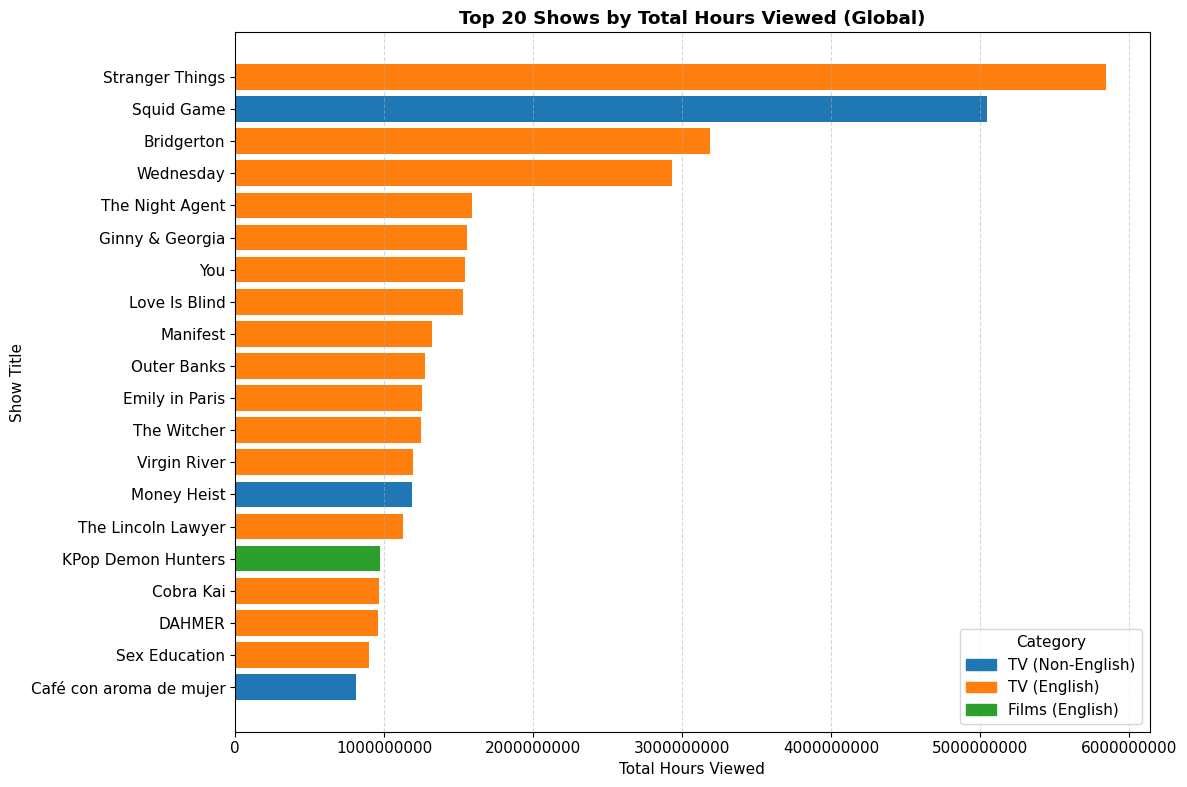

In [13]:
df = con.execute("""
SELECT 
    show_title,
    category,
    SUM(weekly_hours_viewed) AS total_hours,
    SUM(weekly_views) AS total_views
FROM global_alltime
GROUP BY show_title, category
ORDER BY total_hours DESC
LIMIT 20
""").df()

# Sort for proper bar order
df = df.sort_values("total_hours", ascending=True)

plt.figure(figsize=(12, 8))

# Create colors per category
categories = df["category"].unique()
color_map = {cat: i for i, cat in enumerate(categories)}
colors = [plt.cm.tab10(color_map[c]) for c in df["category"]]

# Plot
plt.barh(df["show_title"], df["total_hours"], color=colors)

# Title & labels
plt.title("Top 20 Shows by Total Hours Viewed (Global)")
plt.xlabel("Total Hours Viewed")
plt.ylabel("Show Title")

# Remove scientific notation
plt.ticklabel_format(style='plain', axis='x')

# Legend
handles = [plt.Rectangle((0,0),1,1, color=plt.cm.tab10(i)) for i in range(len(categories))]
plt.legend(handles, categories, title="Category")

# Grid
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

###  Identify Top Performers PER CATEGORY (Films (English), Films (Non-English), TV (English), TV (Non-English))

In [14]:
con.execute("""
SELECT 
    show_title,
    category,
    SUM(weekly_hours_viewed) AS total_hours,
    SUM(weekly_views) AS total_views
FROM global_alltime
GROUP BY show_title, category
ORDER BY total_hours DESC
LIMIT 20
""").df()

,show_title,category,total_hours,total_views
0,Stranger Things,TV (English),5.844980e+09,369000000.0
1,Squid Game,TV (Non-English),5.048300e+09,396900000.0
2,Bridgerton,TV (English),3.185110e+09,344800000.0
3,Wednesday,TV (English),2.931750e+09,197600000.0
4,The Night Agent,TV (English),1.587220e+09,94900000.0
5,Ginny & Georgia,TV (English),1.556880e+09,75100000.0
6,You,TV (English),1.542990e+09,35900000.0
7,Love Is Blind,TV (English),1.530800e+09,94700000.0
8,Manifest,TV (English),1.320520e+09,2800000.0
9,Outer Banks,TV (English),1.275610e+09,51800000.0


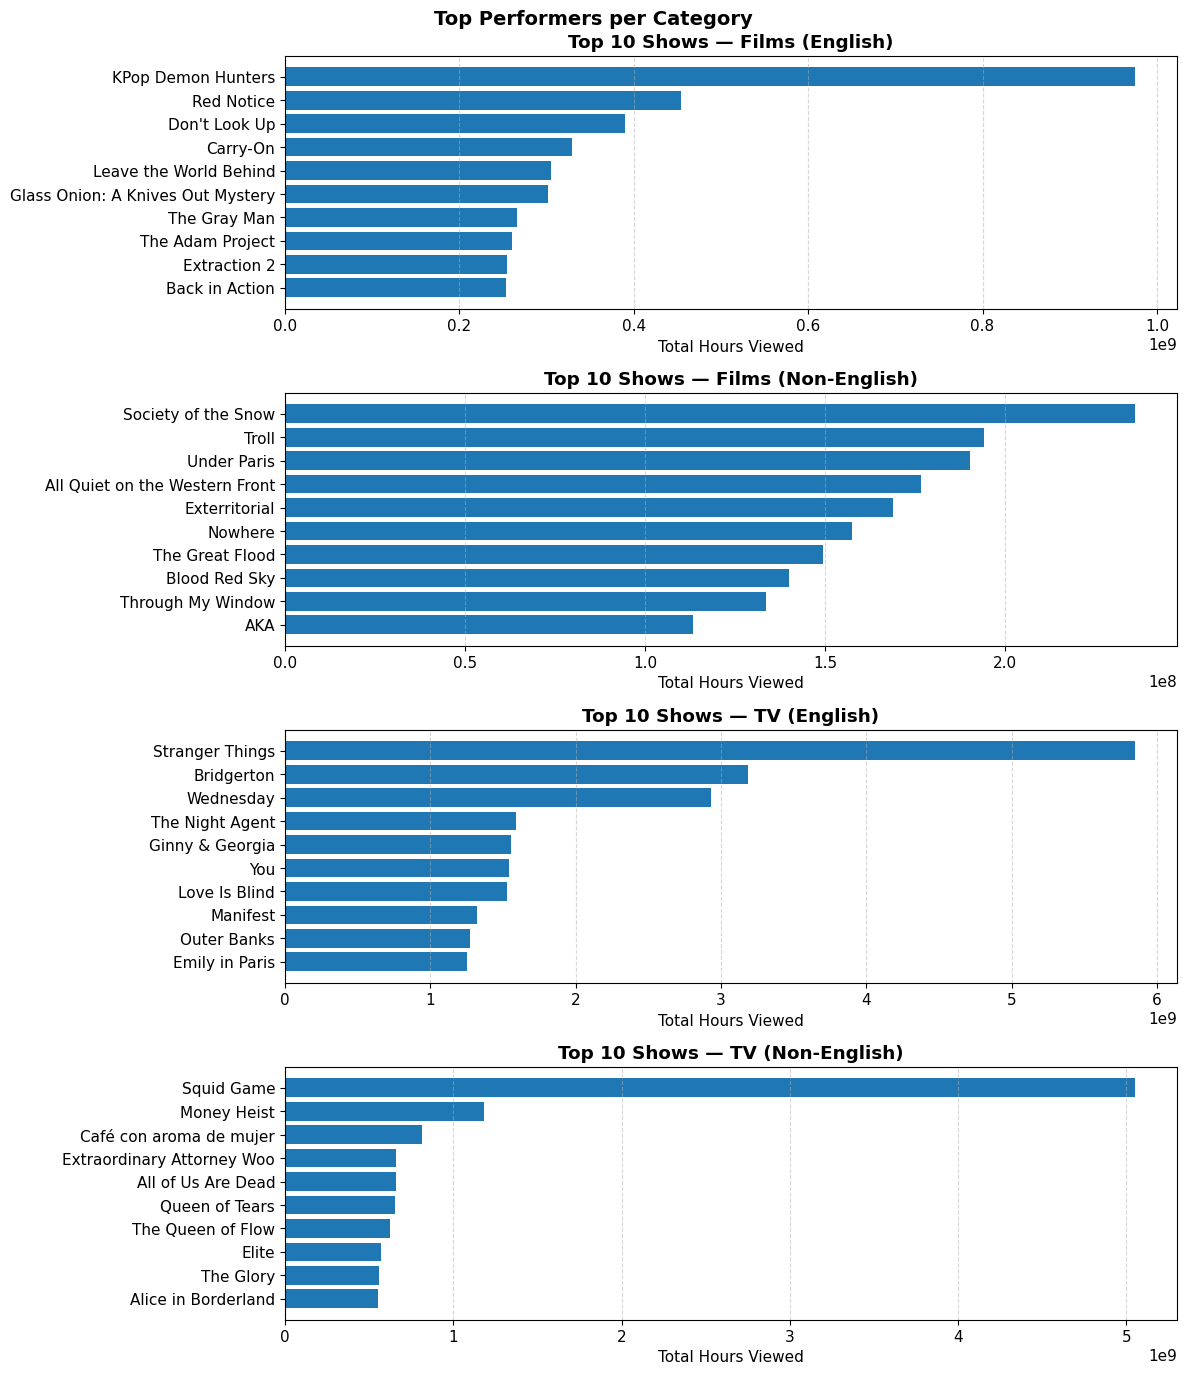

In [15]:
df = con.execute("""
WITH ranked AS (
    SELECT 
        show_title,
        category,
        SUM(weekly_hours_viewed) AS total_hours,
        SUM(weekly_views) AS total_views,
        ROW_NUMBER() OVER (
            PARTITION BY category 
            ORDER BY SUM(weekly_hours_viewed) DESC
        ) AS rank_in_category
    FROM global_alltime
    GROUP BY show_title, category
)
SELECT *
FROM ranked
WHERE rank_in_category <= 10
ORDER BY category, rank_in_category
""").df()

# Ensure proper order within each category (rank 1 at top)
df = df.sort_values(["category", "rank_in_category"])

categories = df["category"].unique()
n = len(categories)

fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(12, 3.5*n), sharex=False)

# If only one category, axes is not a list
if n == 1:
    axes = [axes]

for ax, cat in zip(axes, categories):
    subset = df[df["category"] == cat].copy()
    
    # Plot (rank 1 on top → invert y-axis)
    ax.barh(subset["show_title"], subset["total_hours"])
    ax.invert_yaxis()
    
    # Title per panel
    ax.set_title(f"Top 10 Shows — {cat}")
    ax.set_xlabel("Total Hours Viewed")
    
    # Light grid for readability
    ax.grid(axis="x", linestyle="--", alpha=0.5)

# Global title
fig.suptitle("Top Performers per Category", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

### Category Performance

In [16]:
con.execute("""
SELECT 
    category,
    COUNT(DISTINCT show_title) AS num_titles,
    SUM(weekly_hours_viewed) AS total_hours,
    AVG(weekly_hours_viewed) AS avg_hours
FROM global_alltime
GROUP BY category
ORDER BY total_hours DESC
""").df()

,category,num_titles,total_hours,avg_hours
0,TV (English),559,7.501203e+10,3.049270e+07
1,TV (Non-English),593,4.915031e+10,1.997980e+07
2,Films (English),998,3.574032e+10,1.452859e+07
3,Films (Non-English),1008,1.642596e+10,6.677220e+06


### Content Longevity (Stickiness) OVERALL

In [17]:
con.execute("""
SELECT 
    show_title,
    category,
    MAX(cumulative_weeks_in_top_10) AS weeks_in_top10
FROM global_alltime
GROUP BY show_title, category
ORDER BY weeks_in_top10 DESC
LIMIT 100
        
""").df()

,show_title,category,weeks_in_top10
0,KPop Demon Hunters,Films (English),39
1,Squid Game,TV (Non-English),32
2,"Yo soy Betty, la fea",TV (Non-English),30
3,Stranger Things,TV (English),29
4,Café con aroma de mujer,TV (Non-English),28
...,...,...,...
95,The Christmas Chronicles,Films (English),9
96,Dynamite Kiss,TV (Non-English),9
97,Our Blues,TV (Non-English),9
98,Arcane,TV (English),9


### Content Longevity (Stickiness) PER CATEGORY

In [18]:
con.execute("""
SELECT *
FROM (
    SELECT 
        show_title,
        category,
        MAX(cumulative_weeks_in_top_10) AS weeks_in_top10,
        ROW_NUMBER() OVER (
            PARTITION BY category
            ORDER BY MAX(cumulative_weeks_in_top_10) DESC
        ) AS rank_in_category
    FROM global_alltime
    GROUP BY show_title, category
)
WHERE rank_in_category <= 10
ORDER BY category, rank_in_category
""").df()

,show_title,category,weeks_in_top10,rank_in_category
0,KPop Demon Hunters,Films (English),39,1
1,The Super Mario Bros. Movie,Films (English),24,2
2,The Boss Baby,Films (English),24,3
3,Despicable Me 2,Films (English),19,4
4,Paw Patrol: The Movie,Films (English),17,5
5,Sing,Films (English),17,6
6,Dr. Seuss' The Grinch,Films (English),15,7
7,Shrek,Films (English),15,8
8,Minions,Films (English),14,9
9,Red Notice,Films (English),14,10


### Most engaging contents

In [19]:
con.execute("""
SELECT 
    show_title,
    category,
    SUM(weekly_hours_viewed) * 1.0 
        / NULLIF(SUM(weekly_views), 0) AS hours_per_view
FROM global_alltime
GROUP BY show_title, category
ORDER BY hours_per_view DESC
LIMIT 20
""").df()

,show_title,category,hours_per_view
0,Money Heist,TV (Non-English),790.266667
1,Manifest,TV (English),471.614286
2,The Queen of Flow,TV (Non-English),155.732500
3,The Good Bad Mother,TV (Non-English),102.375000
4,The Mother,Films (English),86.807143
5,The Takedown,Films (Non-English),66.900000
6,Kill Boksoon,Films (Non-English),55.066667
7,Queen Charlotte: A Bridgerton Story,TV (English),53.660396
8,Until You Burn,TV (Non-English),49.333333
9,Falling for Christmas,Films (English),47.733333


### DISTRIBUTION (PARETO ANALYSIS)
Need matplotlib chart

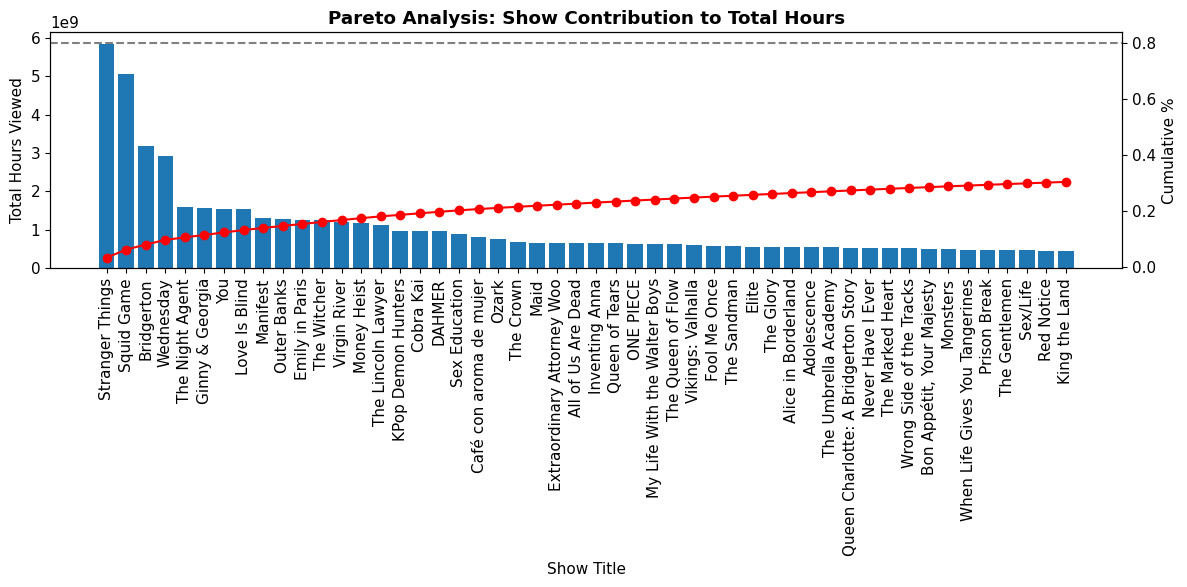

In [20]:
df = con.execute("""
SELECT 
    show_title,
    total_hours,
    SUM(total_hours) OVER (ORDER BY total_hours DESC) * 1.0 
        / SUM(total_hours) OVER () AS cumulative_pct
FROM (
    SELECT 
        show_title,
        SUM(weekly_hours_viewed) AS total_hours
    FROM global_alltime
    GROUP BY show_title
)
ORDER BY total_hours DESC
LIMIT 50
""").df()


fig, ax1 = plt.subplots()

# 🔹 Bar chart (total hours)
ax1.bar(df["show_title"], df["total_hours"])
ax1.set_ylabel("Total Hours Viewed")
ax1.set_xlabel("Show Title")

# Rotate labels (important)
plt.xticks(rotation=90)

# 🔹 Line chart (cumulative %)
ax2 = ax1.twinx()
ax2.plot(df["show_title"], df["cumulative_pct"], color="red", marker="o")
ax2.set_ylabel("Cumulative %")

# 🔹 80% reference line
ax2.axhline(0.8, color="gray", linestyle="--")

# Titles
plt.title("Pareto Analysis: Show Contribution to Total Hours")

plt.tight_layout()
plt.show()

A small number of shows contribute to the majority of total viewing hours, indicating a highly concentrated content performance distribution.

### Rank VS Performance
Does rank actually reflect engagement?

In [21]:
con.execute("""
SELECT 
    weekly_rank,
    AVG(weekly_hours_viewed) AS avg_hours
FROM global_alltime
GROUP BY weekly_rank
ORDER BY weekly_rank
""").df()

,weekly_rank,avg_hours
0,1,5.754234e+07
1,2,2.852981e+07
2,3,2.064468e+07
3,4,1.565848e+07
4,5,1.291489e+07
5,6,1.109574e+07
6,7,9.620701e+06
7,8,8.546037e+06
8,9,7.777429e+06
9,10,6.865650e+06


### Dual KPI Ranking 
- Some titles spike in views but not hours (short content)
- Others dominate hours but not views (long series)
- This gives a multi-metric performance lens

In [22]:
con.execute("""
WITH ranked AS (
    SELECT 
        show_title,
        category,
        SUM(weekly_hours_viewed) AS total_hours,
        SUM(weekly_views) AS total_views,
        ROW_NUMBER() OVER (
            PARTITION BY category 
            ORDER BY SUM(weekly_hours_viewed) DESC
        ) AS rank_by_hours,
        ROW_NUMBER() OVER (
            PARTITION BY category 
            ORDER BY SUM(weekly_views) DESC
        ) AS rank_by_views
    FROM global_alltime
    GROUP BY show_title, category
)

SELECT *
FROM ranked
WHERE rank_by_hours <= 10
   OR rank_by_views <= 10
ORDER BY category, rank_by_hours
""").df()

,show_title,category,total_hours,total_views,rank_by_hours,rank_by_views
0,KPop Demon Hunters,Films (English),974300000.0,584300000.0,1,1
1,Red Notice,Films (English),453990000.0,NaN,2,631
2,Don't Look Up,Films (English),389580000.0,NaN,3,996
3,Carry-On,Films (English),329500000.0,165000000.0,4,2
4,Leave the World Behind,Films (English),304900000.0,128800000.0,5,4
...,...,...,...,...,...,...
57,The Accident,TV (Non-English),325600000.0,49100000.0,26,7
58,Dear Child,TV (Non-English),238300000.0,49400000.0,39,6
59,La Palma,TV (Non-English),202600000.0,66100000.0,46,3
60,DAN DA DAN,TV (Non-English),159200000.0,62100000.0,67,4


# Time Trend KPIs

### OVERALL Monthly Trend | 1 Top Show Per Month

In [23]:
con.execute("""
SELECT *
FROM (
    SELECT 
        DATE_TRUNC('month', STRPTIME(week, '%Y-%m-%d')) AS month,
        show_title,
        SUM(weekly_hours_viewed) AS total_hours,
        ROW_NUMBER() OVER (
            PARTITION BY DATE_TRUNC('month', STRPTIME(week, '%Y-%m-%d'))
            ORDER BY SUM(weekly_hours_viewed) DESC
        ) AS rank_in_month
    FROM global_alltime
    GROUP BY month, show_title
)
WHERE rank_in_month = 1
ORDER BY month
""").df()

,month,show_title,total_hours,rank_in_month
0,2021-07-01,Virgin River,2.735400e+08,1
1,2021-08-01,Outer Banks,4.455500e+08,1
2,2021-09-01,Money Heist,5.932200e+08,1
3,2021-10-01,Squid Game,1.481200e+09,1
4,2021-11-01,Red Notice,3.284800e+08,1
5,2021-12-01,Money Heist,4.669800e+08,1
6,2022-01-01,Café con aroma de mujer,3.841700e+08,1
7,2022-02-01,All of Us Are Dead,4.504600e+08,1
8,2022-03-01,Bridgerton,2.253000e+08,1
9,2022-04-01,Bridgerton,6.095900e+08,1


In [24]:
import matplotlib.pyplot as plt

df = df.sort_values("month")

plt.figure()

# ✅ Use real datetime (NOT string)
plt.plot(df["month"], df["total_hours"], marker="o")

# Vertical show labels (same as yours)
for i in range(len(df)):
    plt.text(
        df["month"].iloc[i],
        df["total_hours"].iloc[i] * 1.02,
        df["show_title"].iloc[i],
        fontsize=8,
        rotation=90,
        ha="center",
        va="bottom"
    )

# ✅ Show fewer x-axis labels (YEAR only)
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title("Top Show per Month (Overall Trend)")
plt.xlabel("Month")
plt.ylabel("Hours Viewed")

plt.xticks(rotation=0)
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

KeyError: 'month'

### OVERALL Monthly Trend | Top 10 Shows Per Month

In [ ]:
df = con.execute("""
WITH base AS (
    SELECT 
        DATE_TRUNC('month', STRPTIME(week, '%Y-%m-%d')) AS month,  
        show_title,
        SUM(weekly_hours_viewed) AS total_hours
    FROM global_alltime
    GROUP BY 
        DATE_TRUNC('month', STRPTIME(week, '%Y-%m-%d')),
        show_title
)
SELECT 
    month,              
    show_title,
    total_hours,
    rank_in_month
FROM (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY month
            ORDER BY total_hours DESC
        ) AS rank_in_month
    FROM base
)
WHERE rank_in_month <= 10
ORDER BY month, rank_in_month
""").df()
display(df)

,month,show_title,total_hours,rank_in_month
0,2021-07-01,Virgin River,273540000.0,1
1,2021-07-01,Sex/Life,232790000.0,2
2,2021-07-01,Manifest,147240000.0,3
3,2021-07-01,Never Have I Ever,125970000.0,4
4,2021-07-01,Elite,115020000.0,5
...,...,...,...,...
565,2026-03-01,The Dinosaurs,62200000.0,6
566,2026-03-01,Virgin River,58000000.0,7
567,2026-03-01,Love Is Blind,57300000.0,8
568,2026-03-01,BAKI-DOU: The Invincible Samurai,42400000.0,9


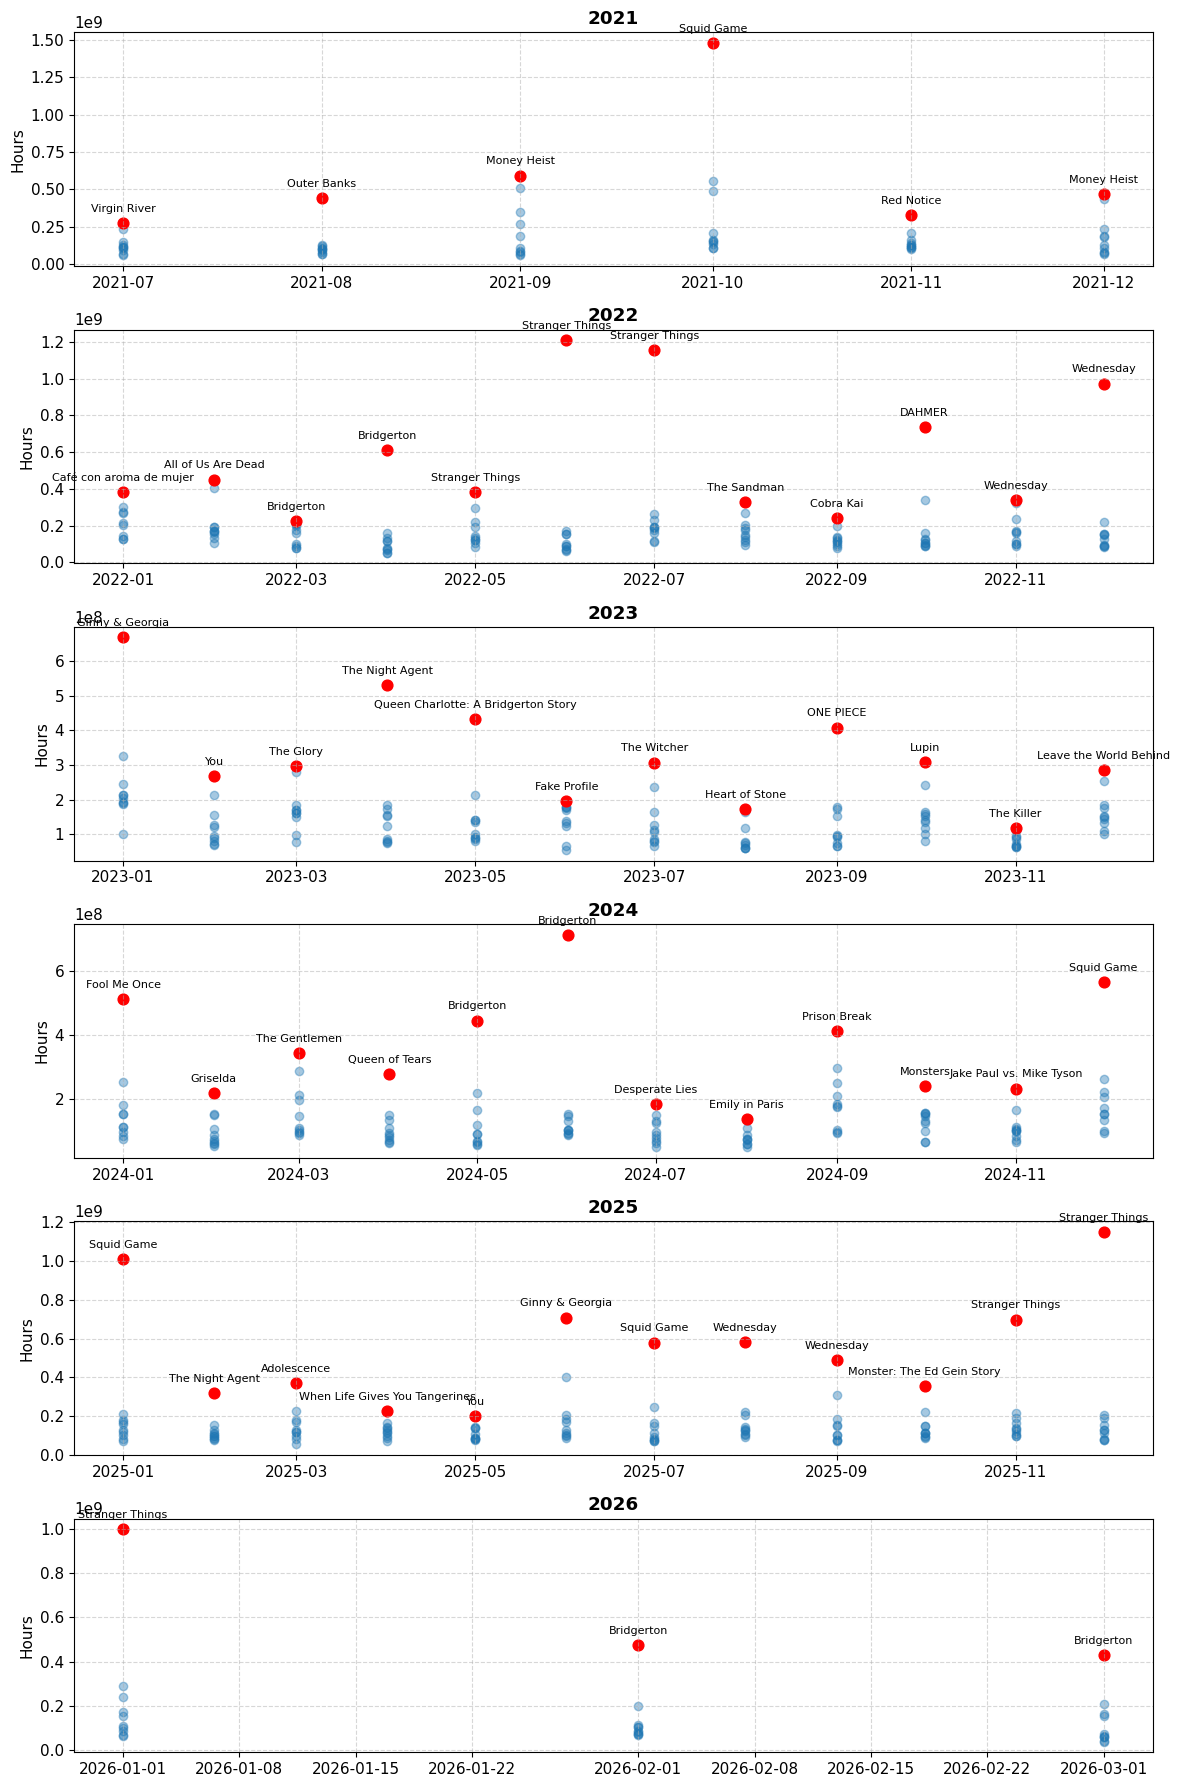

In [ ]:

# Make sure datetime
df["month"] = pd.to_datetime(df["month"])
df["year"] = df["month"].dt.year

years = sorted(df["year"].unique())

fig, axes = plt.subplots(len(years), 1, figsize=(12, 3 * len(years)))

# Fix for single subplot case
if len(years) == 1:
    axes = [axes]

for i, year in enumerate(years):
    
    ax = axes[i]
    subset = df[df["year"] == year]
    
    if subset.empty:
        continue  # safety
    
    # 🔹 Scatter ALL points
    ax.scatter(subset["month"], subset["total_hours"], alpha=0.4)
    
    # 🔹 Highlight top 1
    top1 = subset[subset["rank_in_month"] == 1]
    ax.scatter(top1["month"], top1["total_hours"], color="red", s=60)
    
    # 🔹 Labels (only top 1)
    for _, row in top1.iterrows():
        ax.annotate(
            row["show_title"],
            (row["month"], row["total_hours"]),
            textcoords="offset points",
            xytext=(0, 8),
            ha='center',
            fontsize=8
        )
    
    ax.set_title(f"{year}")
    ax.set_ylabel("Hours")
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### PER CATEGORY Monthly Trend | Top 1 Shows Per Month | Good for charts

In [ ]:
con.execute("""
WITH base AS (
    SELECT 
        DATE_TRUNC('month', STRPTIME(week, '%Y-%m-%d')) AS month,
        category,
        show_title,
        SUM(weekly_hours_viewed) AS total_hours
    FROM global_alltime
    GROUP BY 
        DATE_TRUNC('month', STRPTIME(week, '%Y-%m-%d')),
        category,
        show_title
)

SELECT *
FROM (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY month, category
            ORDER BY total_hours DESC
        ) AS rank_in_month_category
    FROM base
)
WHERE rank_in_month_category = 1
ORDER BY month, category
""").df()

,month,category,show_title,total_hours,rank_in_month_category
0,2021-07-01,Films (English),Fear Street Part 1: 1994,59780000.0,1
1,2021-07-01,Films (Non-English),Major Grom: Plague Doctor,54390000.0,1
2,2021-07-01,TV (English),Virgin River,273540000.0,1
3,2021-07-01,TV (Non-English),Elite,115020000.0,1
4,2021-08-01,Films (English),The Kissing Booth 3,126590000.0,1
...,...,...,...,...,...
223,2026-02-01,TV (Non-English),Single’s Inferno,111100000.0,1
224,2026-03-01,Films (English),War Machine,152000000.0,1
225,2026-03-01,Films (Non-English),Firebreak,34700000.0,1
226,2026-03-01,TV (English),Bridgerton,430600000.0,1


### PER CATEGORY Monthly Trend | Top 10 Shows Per Month | Good for charts

In [ ]:
con.execute("""
SELECT *
FROM (
    SELECT 
        DATE_TRUNC('month', STRPTIME(week, '%Y-%m-%d')) AS month,
        category,
        show_title,
        SUM(weekly_hours_viewed) AS total_hours,
        ROW_NUMBER() OVER (
            PARTITION BY DATE_TRUNC('month', STRPTIME(week, '%Y-%m-%d')), category
            ORDER BY SUM(weekly_hours_viewed) DESC
        ) AS rank_in_month_category
    FROM global_alltime
    GROUP BY 
        DATE_TRUNC('month', STRPTIME(week, '%Y-%m-%d')),
        category,
        show_title
)
WHERE rank_in_month_category <= 10
ORDER BY month, category, rank_in_month_category
""").df()

,month,category,show_title,total_hours,rank_in_month_category
0,2021-07-01,Films (English),Fear Street Part 1: 1994,59780000.0,1
1,2021-07-01,Films (English),Fatherhood,46300000.0,2
2,2021-07-01,Films (English),Fear Street Part 2: 1978,41980000.0,3
3,2021-07-01,Films (English),Wish Dragon,34400000.0,4
4,2021-07-01,Films (English),Fear Street Part 3: 1666,32430000.0,5
...,...,...,...,...,...
2275,2026-03-01,TV (Non-English),Unfamiliar,23400000.0,6
2276,2026-03-01,TV (Non-English),That Night,15600000.0,7
2277,2026-03-01,TV (Non-English),"A Friend, a Murderer",15000000.0,8
2278,2026-03-01,TV (Non-English),DOC,14500000.0,9


### OVERALL Shows | Top 1 Show PER YEAR

In [ ]:
con.execute("""
WITH base AS (
    SELECT 
        DATE_TRUNC('year', STRPTIME(week, '%Y-%m-%d')) AS year,
        show_title,
        SUM(weekly_hours_viewed) AS total_hours
    FROM global_alltime
    GROUP BY 
        DATE_TRUNC('year', STRPTIME(week, '%Y-%m-%d')),
        show_title
)

SELECT *
FROM (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY year
            ORDER BY total_hours DESC
        ) AS rank_in_year
    FROM base
)
WHERE rank_in_year = 1
ORDER BY year
""").df()

,year,show_title,total_hours,rank_in_year
0,2021-01-01,Squid Game,2.226950e+09,1
1,2022-01-01,Stranger Things,2.967980e+09,1
2,2023-01-01,Ginny & Georgia,7.888800e+08,1
3,2024-01-01,Bridgerton,1.239400e+09,1
4,2025-01-01,Squid Game,2.165700e+09,1
5,2026-01-01,Stranger Things,1.027400e+09,1


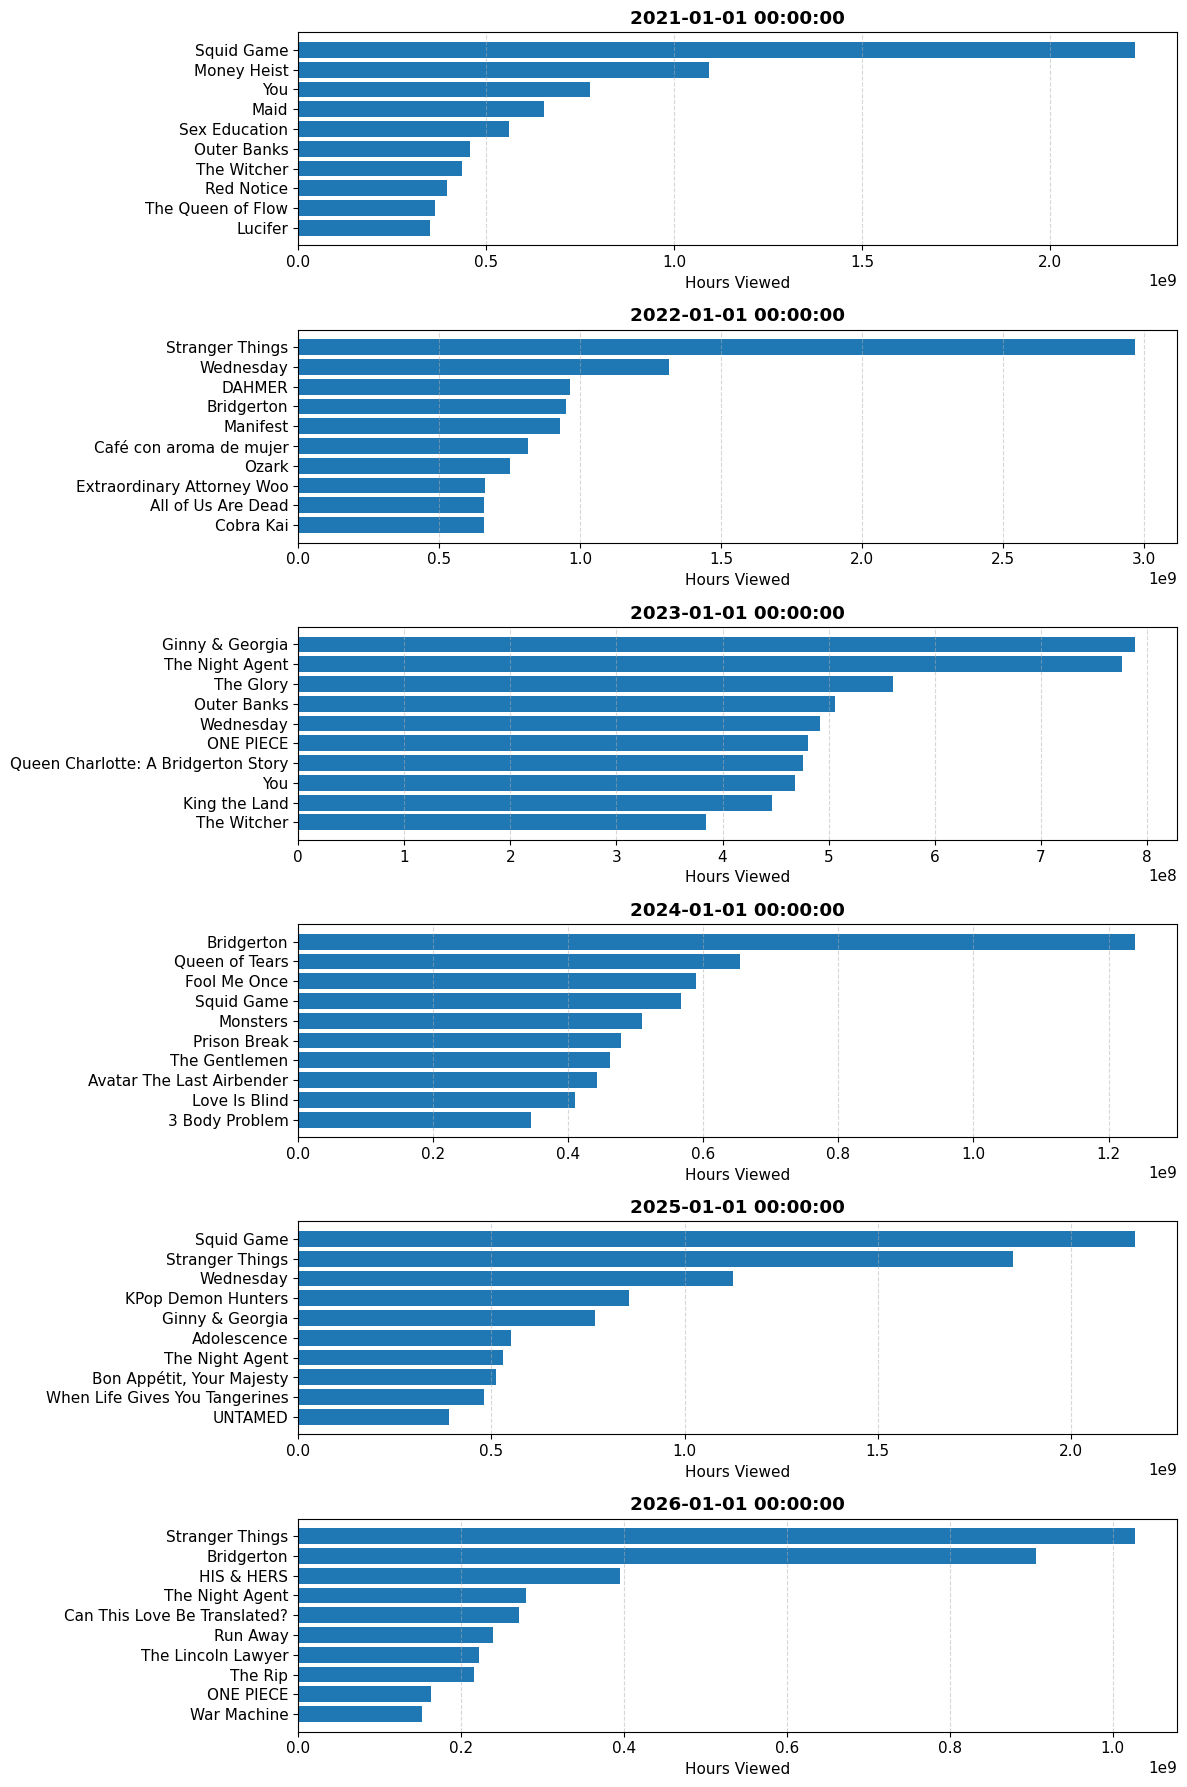

In [ ]:
df = con.execute("""
WITH base AS (
    SELECT 
        DATE_TRUNC('year', STRPTIME(week, '%Y-%m-%d')) AS year,
        show_title,
        SUM(weekly_hours_viewed) AS total_hours
    FROM global_alltime
    GROUP BY 
        DATE_TRUNC('year', STRPTIME(week, '%Y-%m-%d')),
        show_title
)
SELECT *
FROM (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY year
            ORDER BY total_hours DESC
        ) AS rank_in_year
    FROM base
)
WHERE rank_in_year <= 10
ORDER BY year, rank_in_year
""").df()

years = df["year"].unique()

fig, axes = plt.subplots(len(years), 1, figsize=(12, 3 * len(years)))

if len(years) == 1:
    axes = [axes]

for i, year in enumerate(years):
    
    ax = axes[i]
    subset = df[df["year"] == year].sort_values("total_hours")
    
    ax.barh(subset["show_title"], subset["total_hours"])
    
    ax.set_title(f"{year}")
    ax.set_xlabel("Hours Viewed")
    ax.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### PER CATEGORY Shows | Top Shows PER YEAR

In [ ]:

con.execute("""
WITH base AS (
    SELECT 
        DATE_TRUNC('year', STRPTIME(week, '%Y-%m-%d')) AS year,
        category,
        show_title,
        SUM(weekly_hours_viewed) AS total_hours
    FROM global_alltime
    GROUP BY 
        DATE_TRUNC('year', STRPTIME(week, '%Y-%m-%d')),
        category,
        show_title
)

SELECT *
FROM (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY year, category
            ORDER BY total_hours DESC
        ) AS rank_in_year_category
    FROM base
)
WHERE rank_in_year_category = 1
ORDER BY year, category
""").df()

,year,category,show_title,total_hours,rank_in_year_category
0,2021-01-01,Films (English),Red Notice,3.967400e+08,1
1,2021-01-01,Films (Non-English),Blood Red Sky,1.205900e+08,1
2,2021-01-01,TV (English),You,7.774800e+08,1
3,2021-01-01,TV (Non-English),Squid Game,2.226950e+09,1
4,2022-01-01,Films (English),Don't Look Up,2.785500e+08,1
5,2022-01-01,Films (Non-English),Troll,1.523500e+08,1
6,2022-01-01,TV (English),Stranger Things,2.967980e+09,1
7,2022-01-01,TV (Non-English),Café con aroma de mujer,8.134800e+08,1
8,2023-01-01,Films (English),Leave the World Behind,2.862000e+08,1
9,2023-01-01,Films (Non-English),Nowhere,1.506000e+08,1


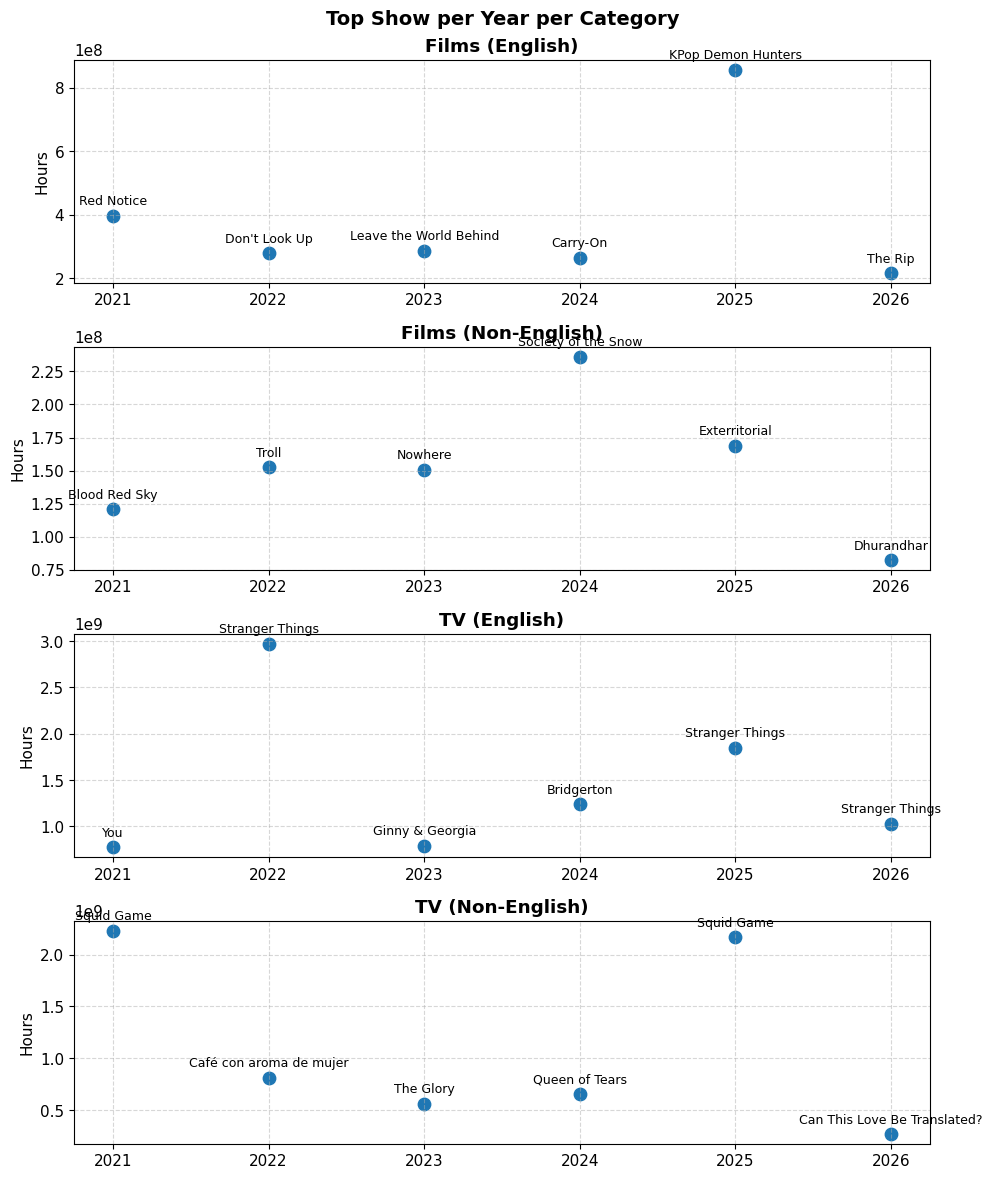

In [ ]:
df = con.execute("""
WITH base AS (
    SELECT 
        DATE_TRUNC('year', STRPTIME(week, '%Y-%m-%d')) AS year,
        category,
        show_title,
        SUM(weekly_hours_viewed) AS total_hours
    FROM global_alltime
    GROUP BY 
        DATE_TRUNC('year', STRPTIME(week, '%Y-%m-%d')),
        category,
        show_title
)
SELECT *
FROM (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY year, category
            ORDER BY total_hours DESC
        ) AS rank_in_year_category
    FROM base
)
WHERE rank_in_year_category = 1
ORDER BY year, category
""").df()

# Ensure proper format
df["year"] = pd.to_datetime(df["year"]).dt.year

categories = df["category"].unique()

fig, axes = plt.subplots(len(categories), 1, figsize=(10, 3 * len(categories)))

if len(categories) == 1:
    axes = [axes]

for i, cat in enumerate(categories):
    
    ax = axes[i]
    subset = df[df["category"] == cat]
    
    # Scatter (no misleading lines)
    ax.scatter(subset["year"], subset["total_hours"], s=80)
    
    # Labels
    for _, row in subset.iterrows():
        ax.annotate(
            row["show_title"],
            (row["year"], row["total_hours"]),
            textcoords="offset points",
            xytext=(0, 8),
            ha='center',
            fontsize=9
        )
    
    ax.set_title(f"{cat}")
    ax.set_ylabel("Hours")
    ax.set_xticks(subset["year"])
    ax.grid(True, linestyle="--", alpha=0.5)

fig.suptitle("Top Show per Year per Category", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()